## Student Performance Indicator


Life cycle of Machine Learning Project


1. understand the problem statement
2. data collection
3. data checskto perform 
4. EDA
5. Data preprocession
6. Model Training 
7. choose best Model 

# Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:

df = pd.read_csv('data/stud.csv')

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


* Dataset information
gender : sex of students -> (Male/female)
race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
lunch : having lunch before test (standard or free/reduced)
test preparation course : complete or not complete before test
math score
reading score
writing score

3. Data Checks to perform
3.1. Check Missing values
3.2. Check Duplicates
3.3. Check data type
3.4. Check the number of unique values of each column
3.5. Check statistics of data set
3.6. Check various categories present in the different categorical column

In [4]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


* insight 
1. all means are in beetween 66 and 68.05
2. standard deviation are in range of 14.6 to 15.2
3. min score of in math is 0 then in writing score is 10 and then reading score is 17
and max score for all is 100

In [8]:
print("Catagories in gender and their counts:",end=" ")
print(df['gender'].value_counts())

print('catagories in race in their counts:',end=" ")
print(df['race_ethnicity'].value_counts())

print('catagories in parental level education in their counts:',end=" ")
print(df['parental_level_of_education'].value_counts())

print('catagories in lunch in their counts:',end=" ")
print(df['lunch'].value_counts())

print('catagories in test preparation in their counts:',end=" ")
print(df['test_preparation_course'].value_counts())

Catagories in gender and their counts: gender
female    518
male      482
Name: count, dtype: int64
catagories in race in their counts: race_ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
catagories in parental level education in their counts: parental_level_of_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
catagories in lunch in their counts: lunch
standard        645
free/reduced    355
Name: count, dtype: int64
catagories in test preparation in their counts: test_preparation_course
none         642
completed    358
Name: count, dtype: int64


In [9]:
# define and numerical features 
numeric_features=[feture for feture in df.columns if df[feture].dtype !='O']
categorical_features=[feture for feture in df.columns if df[feture].dtype =='O']

print('we have {} numirical feture : {} '.format(len(numeric_features),numeric_features))
print('we have {} categorical feture : {} '.format(len(categorical_features),categorical_features))

we have 3 numirical feture : ['math_score', 'reading_score', 'writing_score'] 
we have 5 categorical feture : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course'] 


In [10]:
# adding column for Total score and average score 
df['Total score']=df['math_score']+df['reading_score']+df['writing_score']
df['average_score'] = df['Total score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [12]:
reading_full = df[df['reading_score']==100]['average_score'].count()
math_full = df[df['math_score']==100]['average_score'].count()
writing_full = df[df['writing_score']==100]['average_score'].count()

print(f'Number of students with full marks in maths:{math_full}')
print(f'Number of students with full marks in writing:{writing_full}')
print(f'Number of students with full marks in reading:{reading_full}')

Number of students with full marks in maths:7
Number of students with full marks in writing:14
Number of students with full marks in reading:17


In [13]:
reading_less_20=df[df['reading_score']<=20]['average_score'].count()
writing_less_20=df[df['writing_score']<=20]['average_score'].count()
math_less_20=df[df['math_score']<=20]['average_score'].count()

print(f'Number of students with marks less the 20 \n in maths is {math_less_20},\n in reading is {reading_less_20} \n and in writing is {writing_less_20}')

Number of students with marks less the 20 
 in maths is 4,
 in reading is 1 
 and in writing is 3


performance of students is worse in maths and best in reading

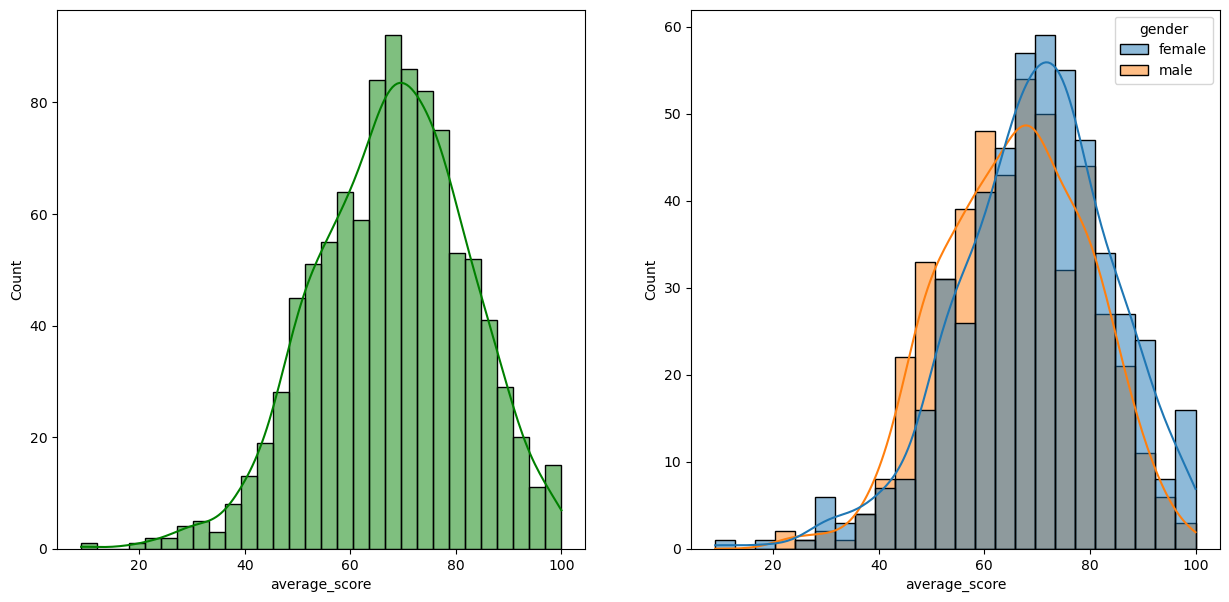

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

sns.histplot(df, x='average_score', bins=30, kde=True, color='g', ax=axs[0])

sns.histplot(df, x='average_score', kde=True, hue='gender', ax=axs[1])

plt.show()

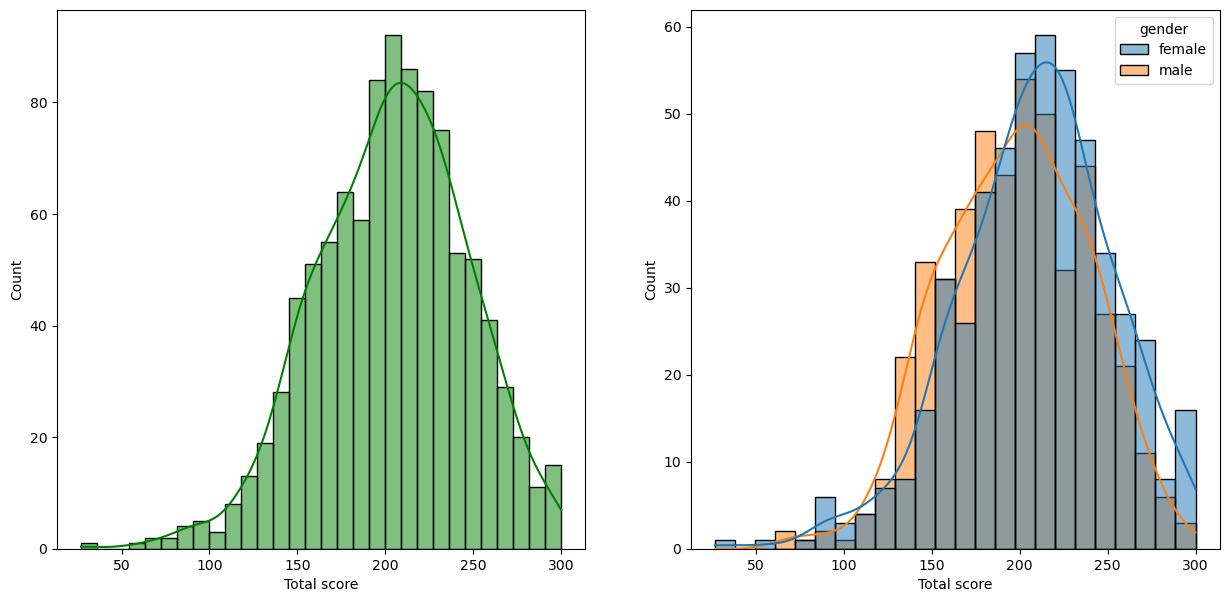

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

sns.histplot(df, x='Total score', bins=30, kde=True, color='g', ax=axs[0])

sns.histplot(df, x='Total score', kde=True, hue='gender', ax=axs[1])

plt.show()

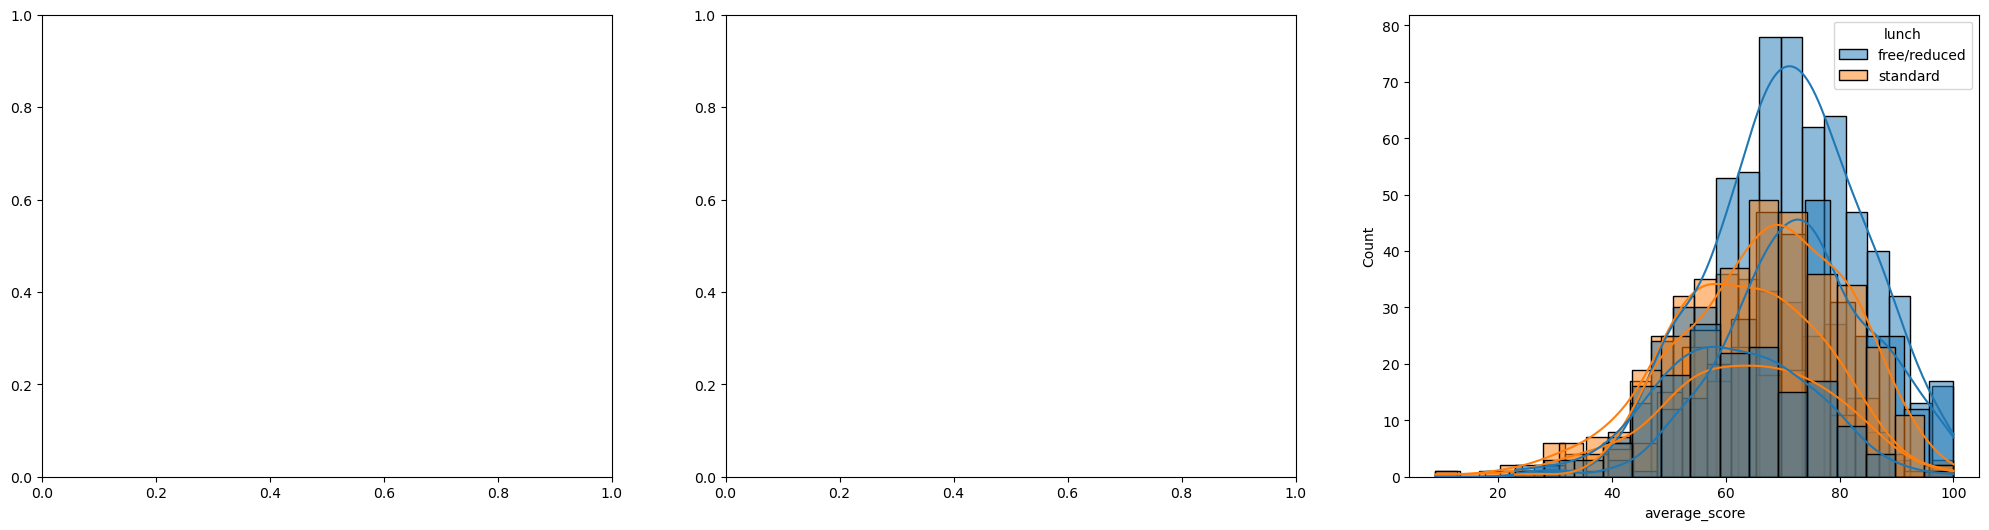

In [22]:
plt.subplots(1,3,figsize=(25,6))
sns.histplot(data=df,x='average_score',kde=True,hue='lunch')

sns.histplot(data=df[df.gender=='female'],x='average_score',kde=True,hue='lunch')

sns.histplot(data=df[df.gender=='male'],x='average_score',kde=True,hue='lunch')
plt.show()

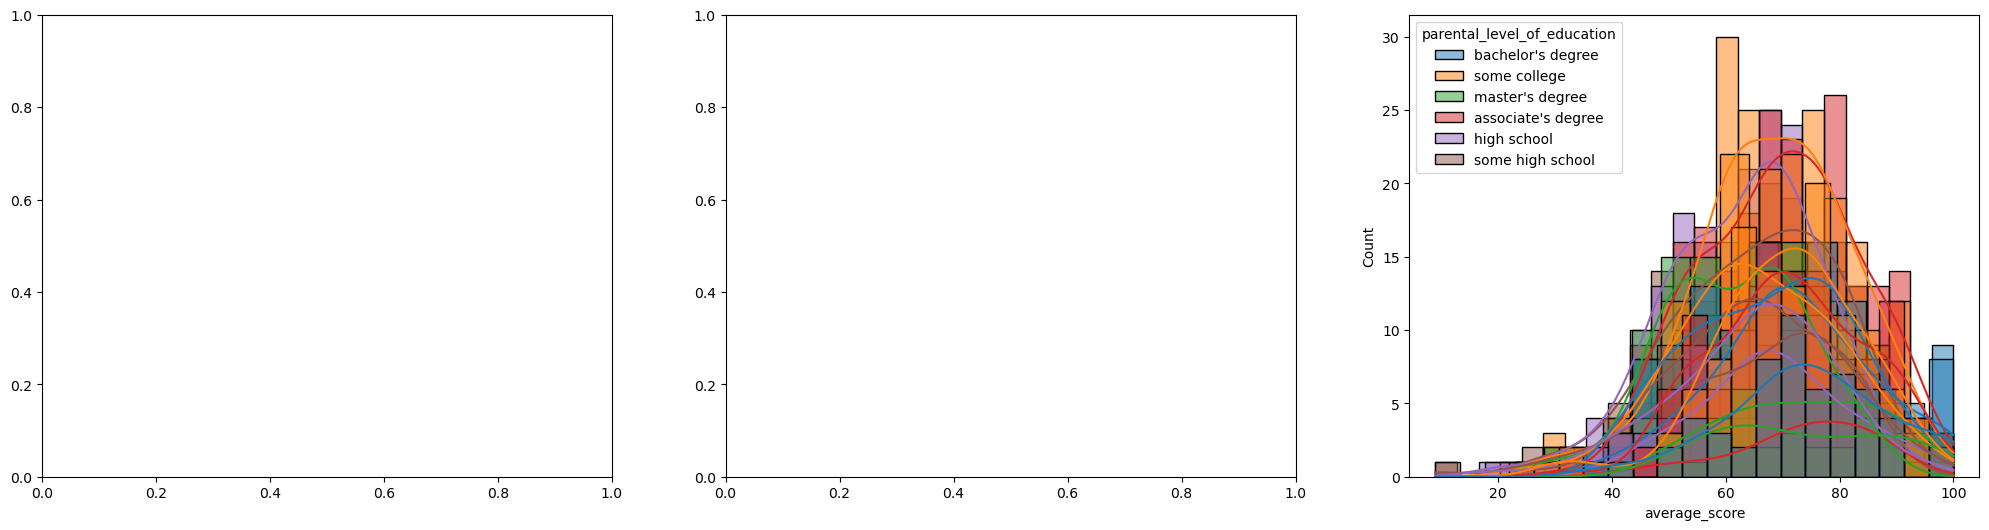

In [26]:
plt.subplots(1,3,figsize=(25,6))

ax =sns.histplot(data=df,x='average_score',kde=True,hue='parental_level_of_education')

ax =sns.histplot(data=df[df.gender=='male'],x='average_score',kde=True,hue='parental_level_of_education')

ax =sns.histplot(data=df[df.gender=='female'],x='average_score',kde=True,hue='parental_level_of_education')
plt.show()

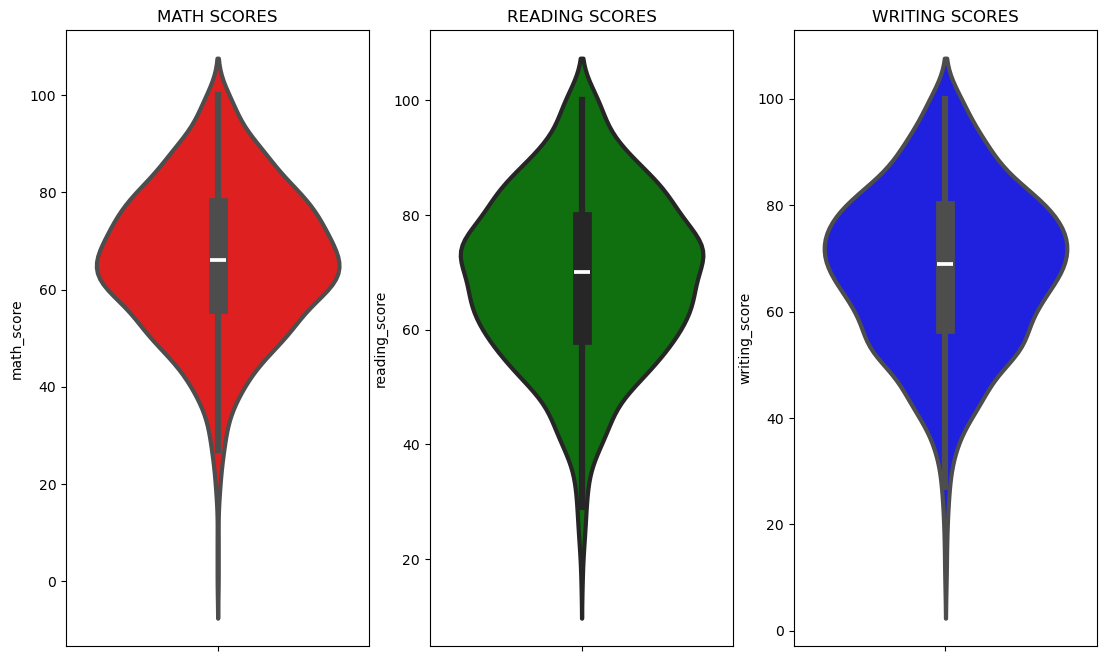

In [28]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

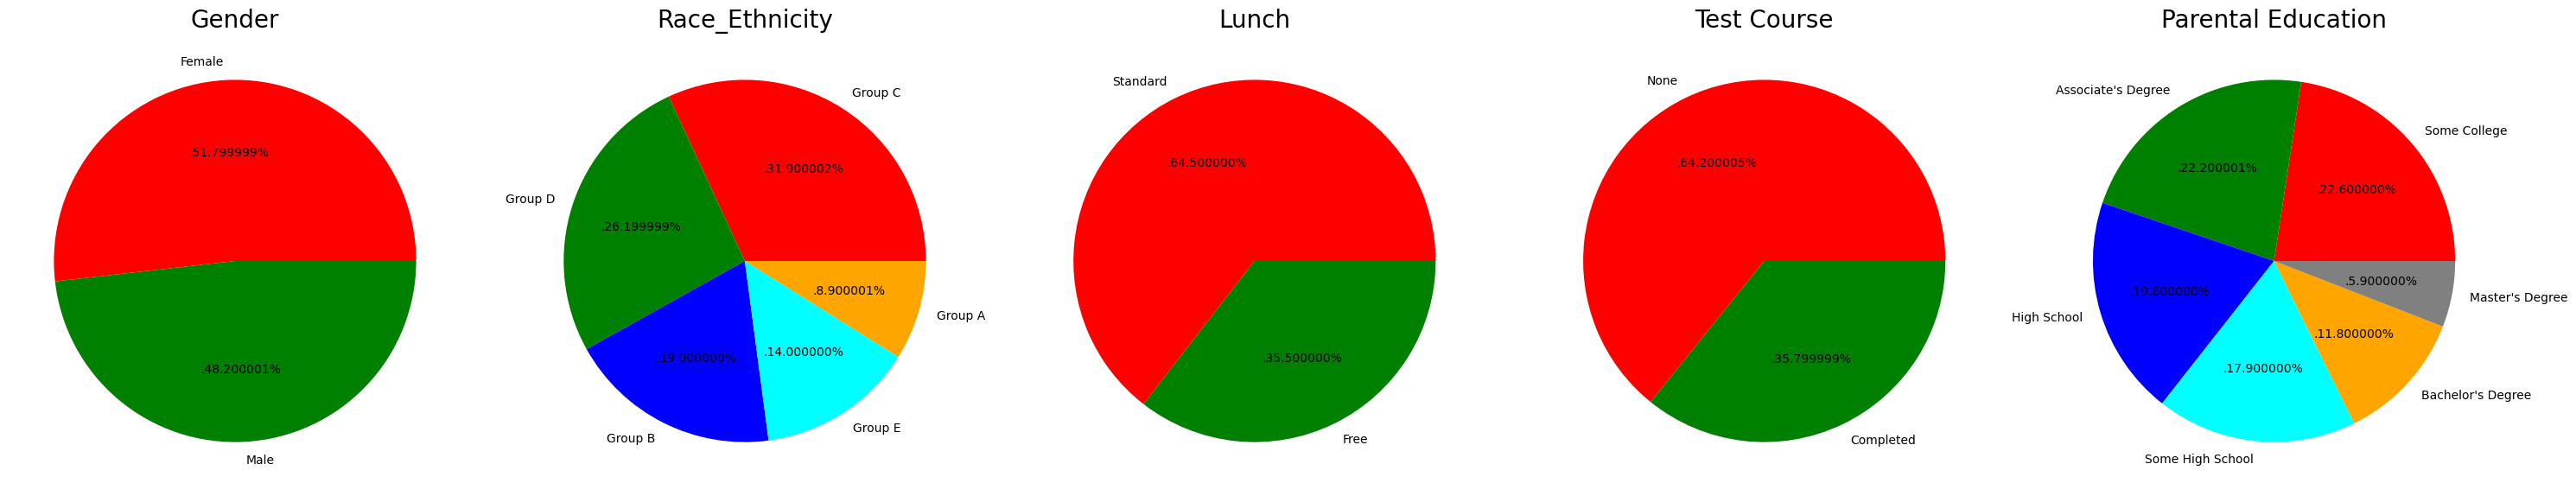

In [31]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race_Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

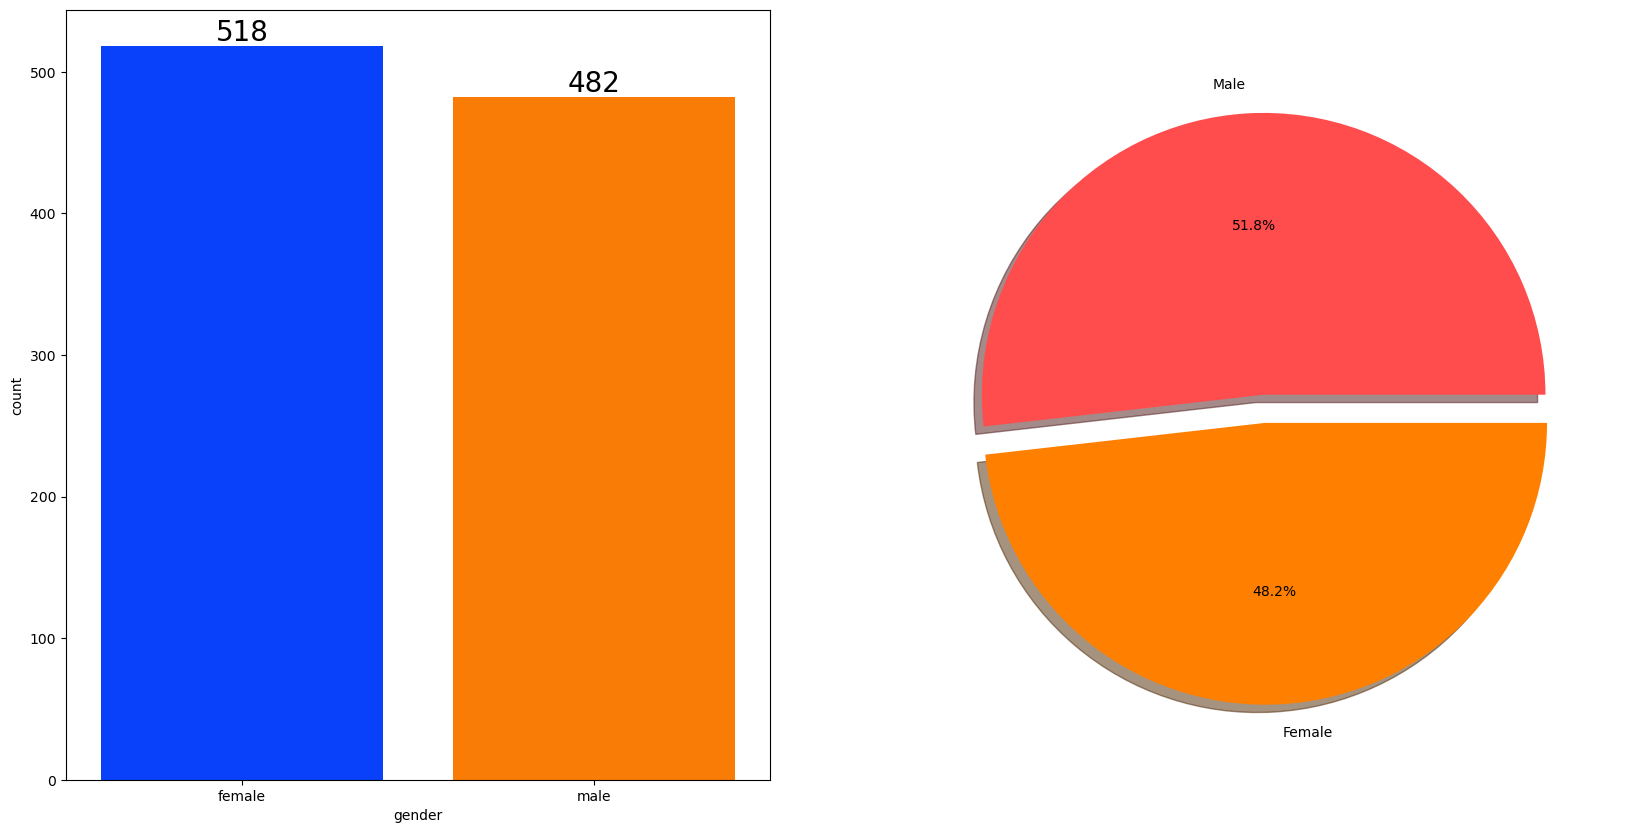

In [32]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

In [36]:
gender_group = df.groupby('gender')
gender_group

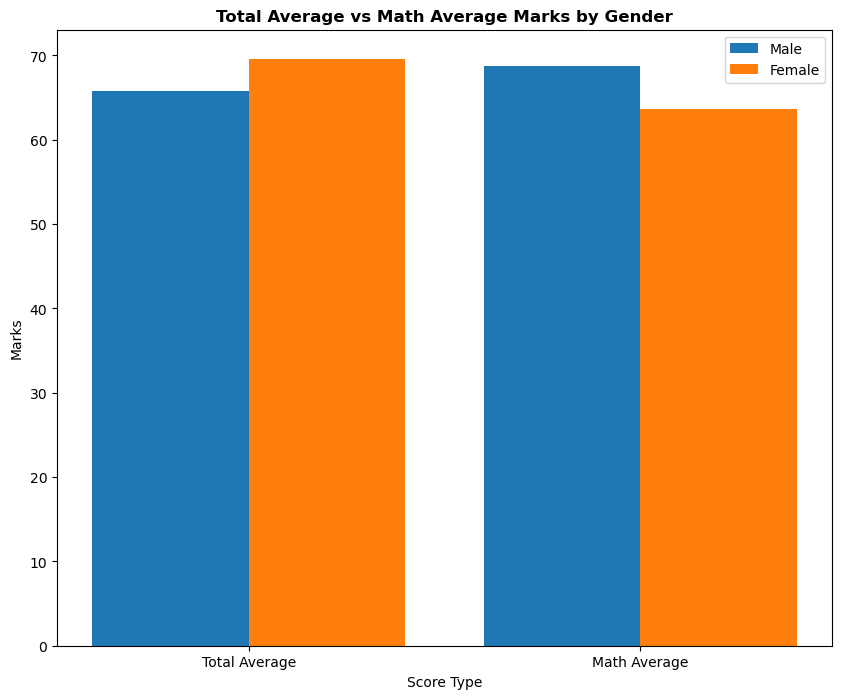

In [39]:
# Group by gender and calculate the mean
gender_group = df.groupby('gender')[['average_score', 'math_score']].mean()

plt.figure(figsize=(10, 8))

X = ['Total Average', 'Math Average']

female_scores = [
    gender_group.loc['female', 'average_score'],
    gender_group.loc['female', 'math_score']
]

male_scores = [
    gender_group.loc['male', 'average_score'],
    gender_group.loc['male', 'math_score']
]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, width=0.4, label='Male')
plt.bar(X_axis + 0.2, female_scores, width=0.4, label='Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.xlabel("Score Type")
plt.title("Total Average vs Math Average Marks by Gender", fontweight='bold')
plt.legend()

plt.show()

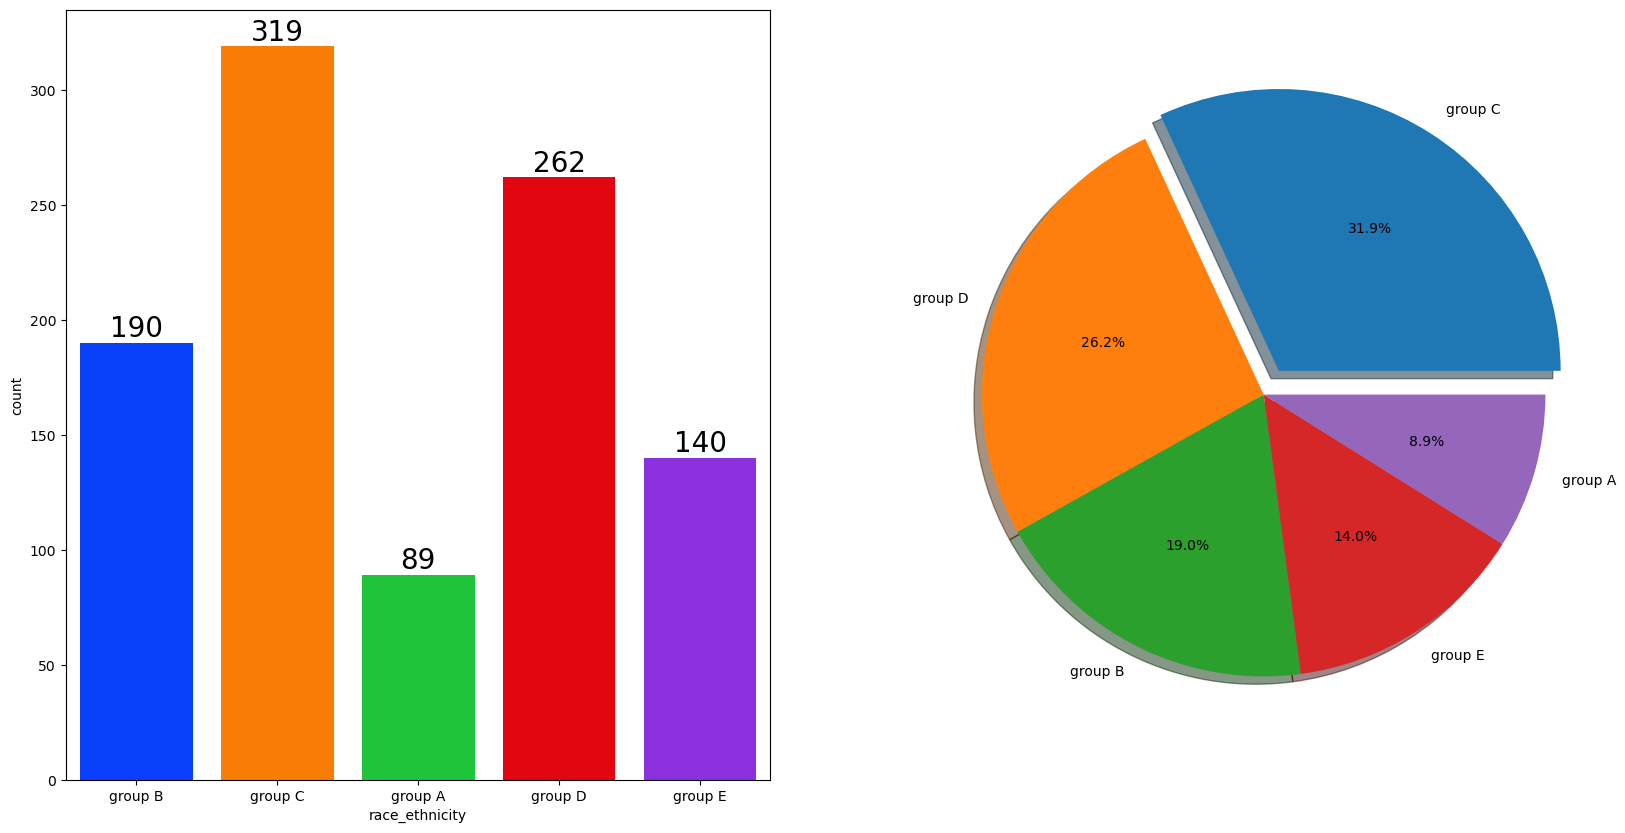

In [35]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()

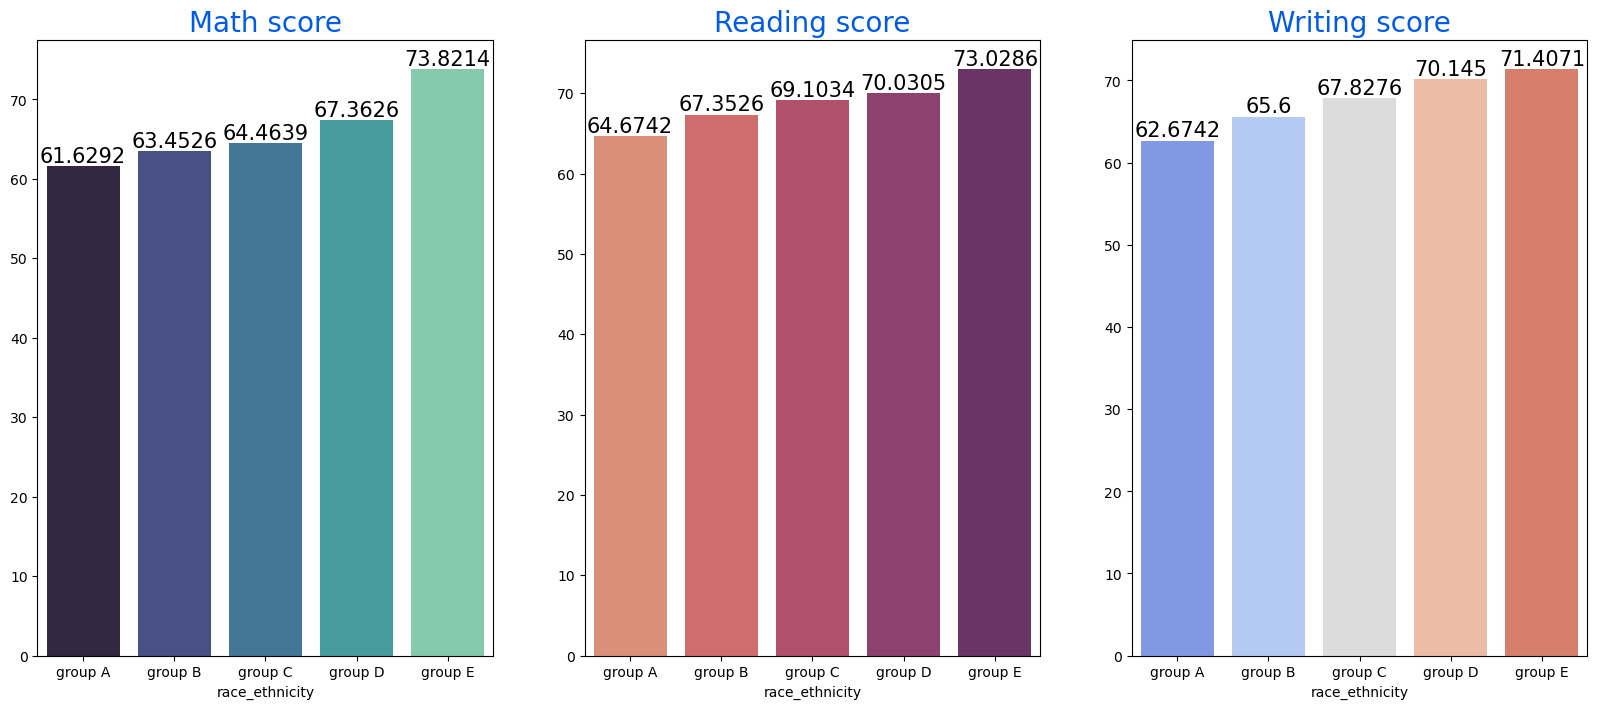

In [41]:
Group_data2=df.groupby('race_ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index,y=Group_data2['writing_score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

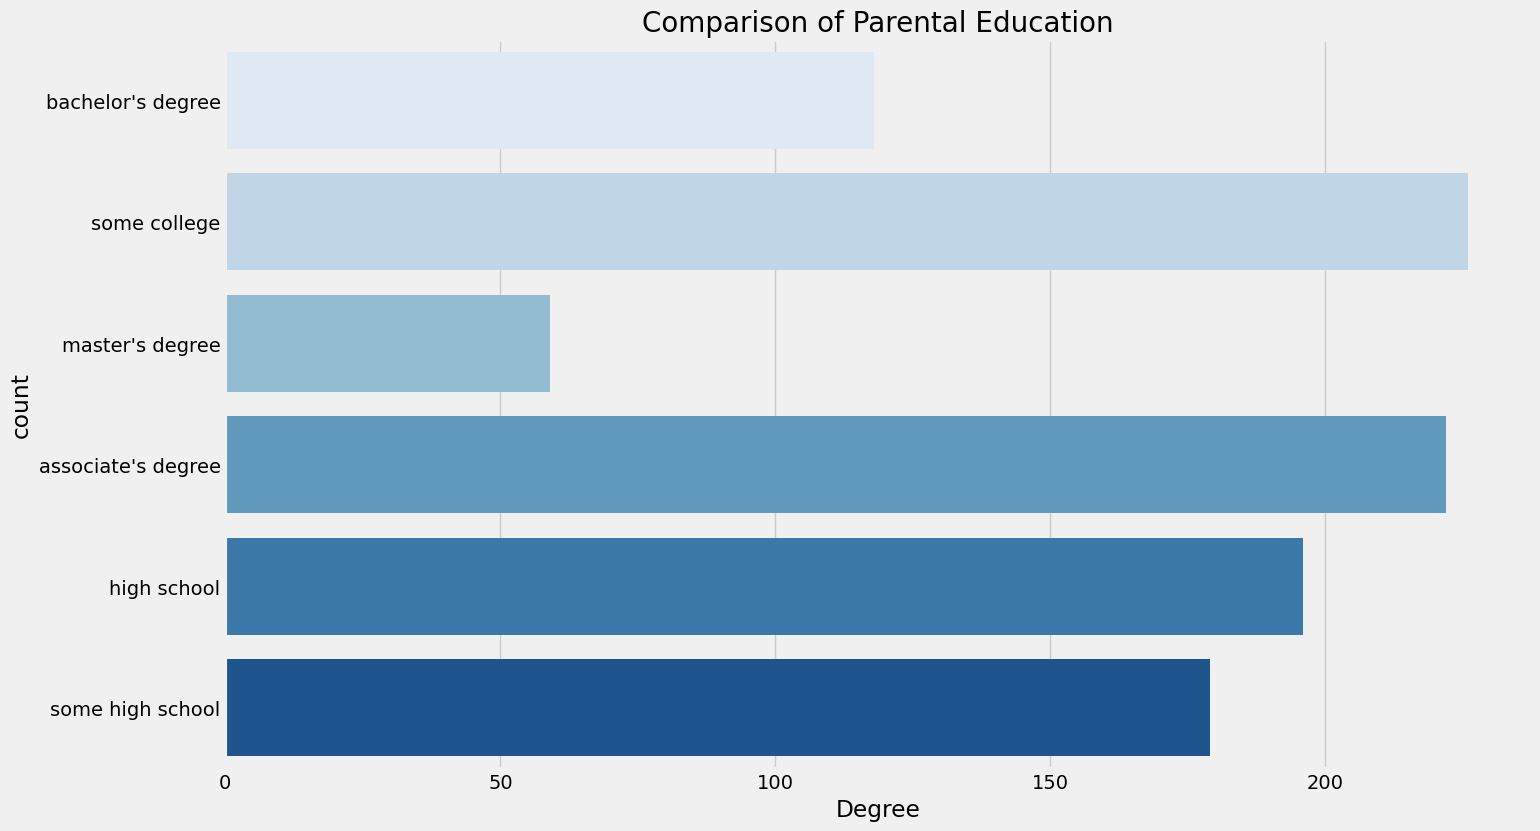

In [43]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

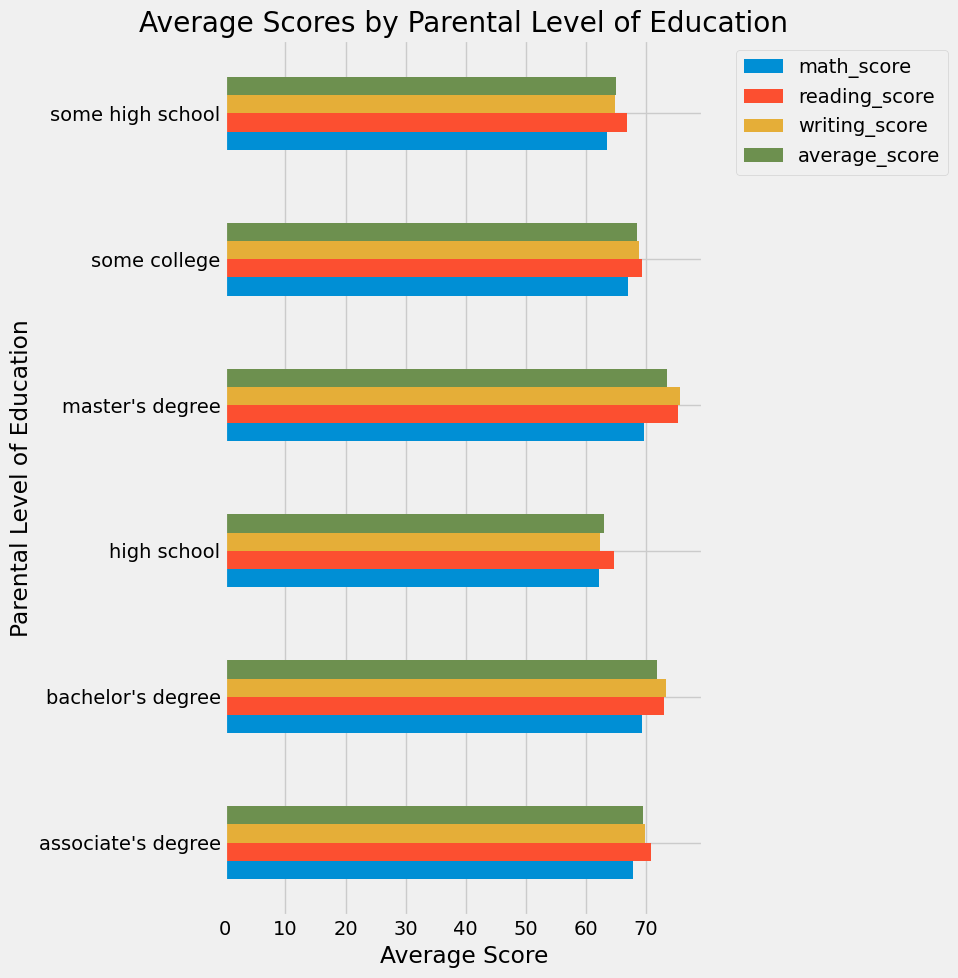

In [48]:
score_cols = ['math_score', 'reading_score', 'writing_score', 'average_score']

(df.groupby('parental_level_of_education')[score_cols]
   .mean()
   .plot(kind='barh', figsize=(10, 10)))

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Average Score")
plt.ylabel("Parental Level of Education")
plt.title("Average Scores by Parental Level of Education")

plt.tight_layout()
plt.show()

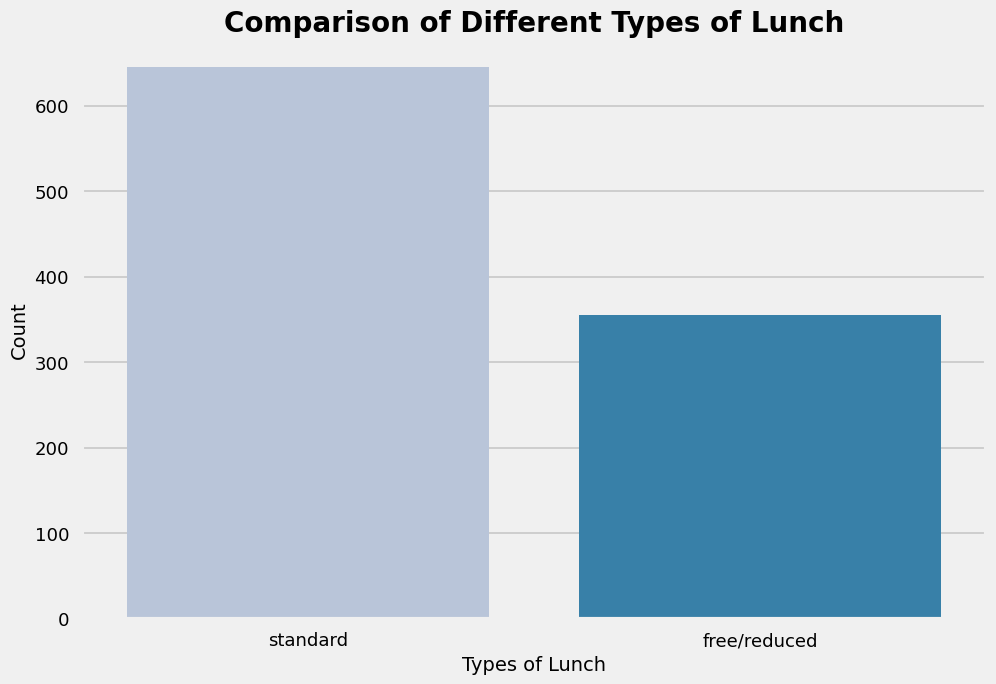

In [51]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-v0_8-talk')  # Updated style name

sns.countplot(
    data=df,
    x='lunch',
    hue='lunch',          # Required when using palette in Seaborn 0.13+
    palette='PuBu',
    legend=False
)

plt.title('Comparison of Different Types of Lunch', fontsize=20, fontweight='bold')
plt.xlabel('Types of Lunch', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.show()

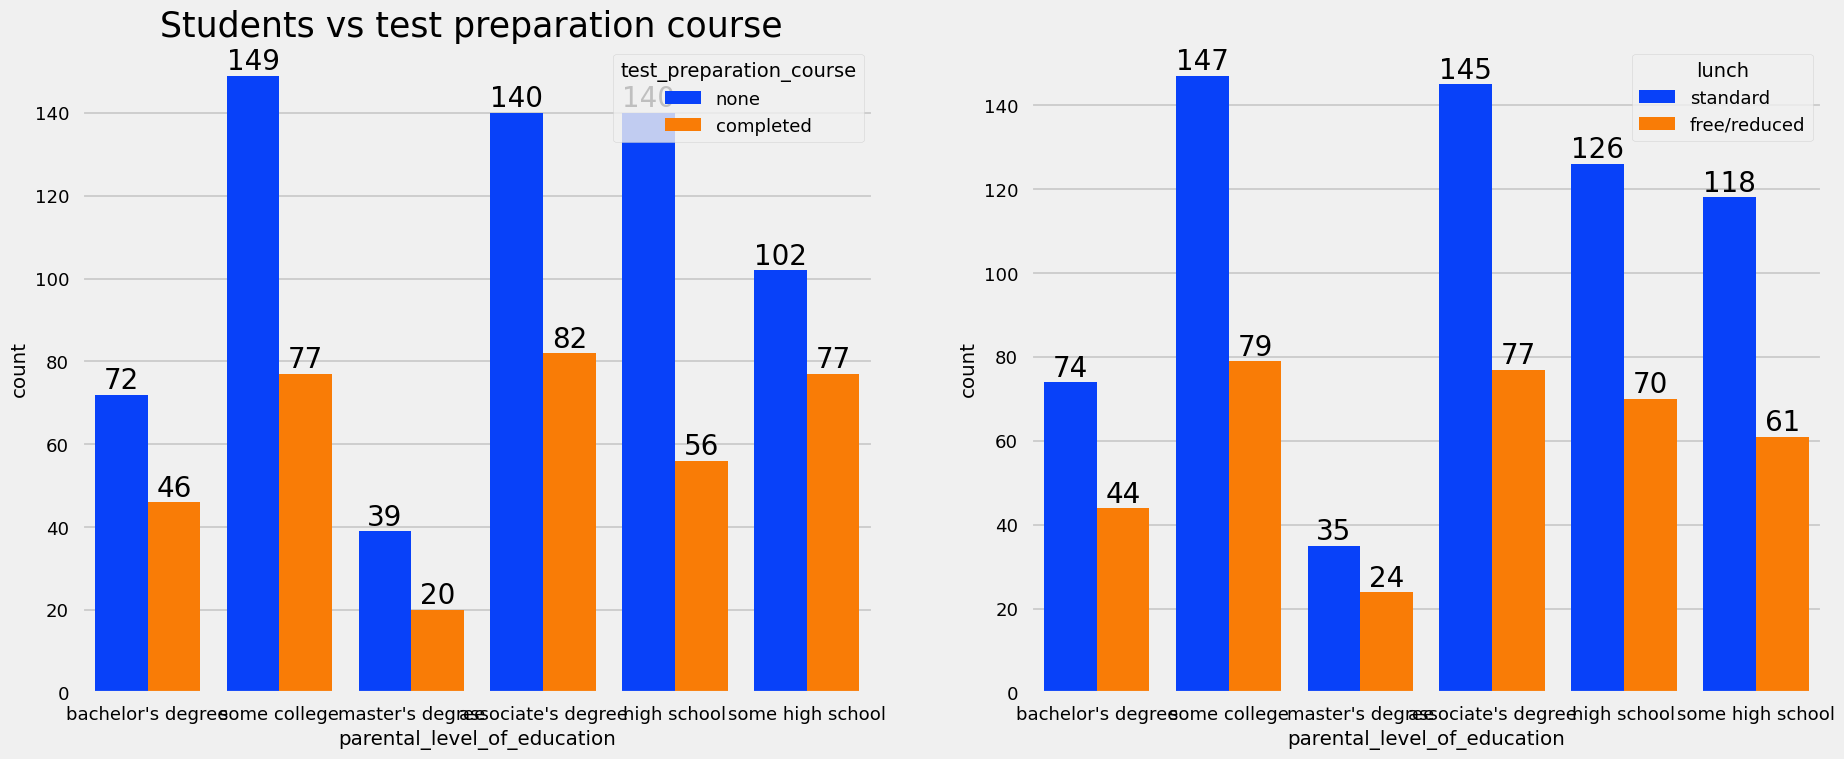

In [53]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='test_preparation_course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20) 

<Axes: xlabel='lunch', ylabel='math_score'>

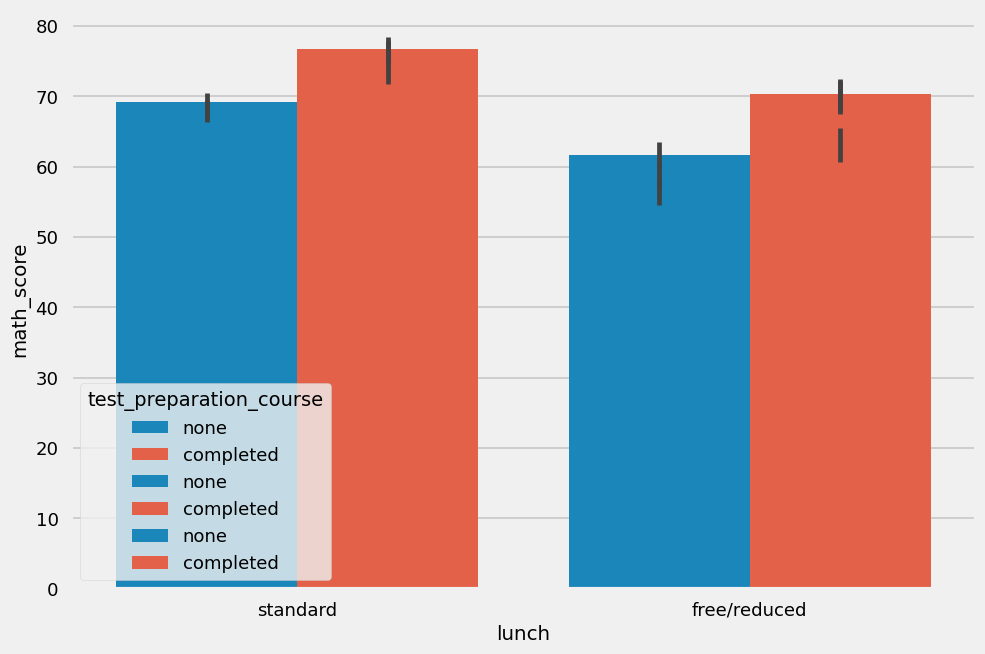

In [62]:


sns.barplot (x=df['lunch'], y=df['math_score'], hue=df['test_preparation_course'])
sns.barplot (x=df['lunch'], y=df['reading_score'], hue=df['test_preparation_course'])
sns.barplot (x=df['lunch'], y=df['writing_score'], hue=df['test_preparation_course'])

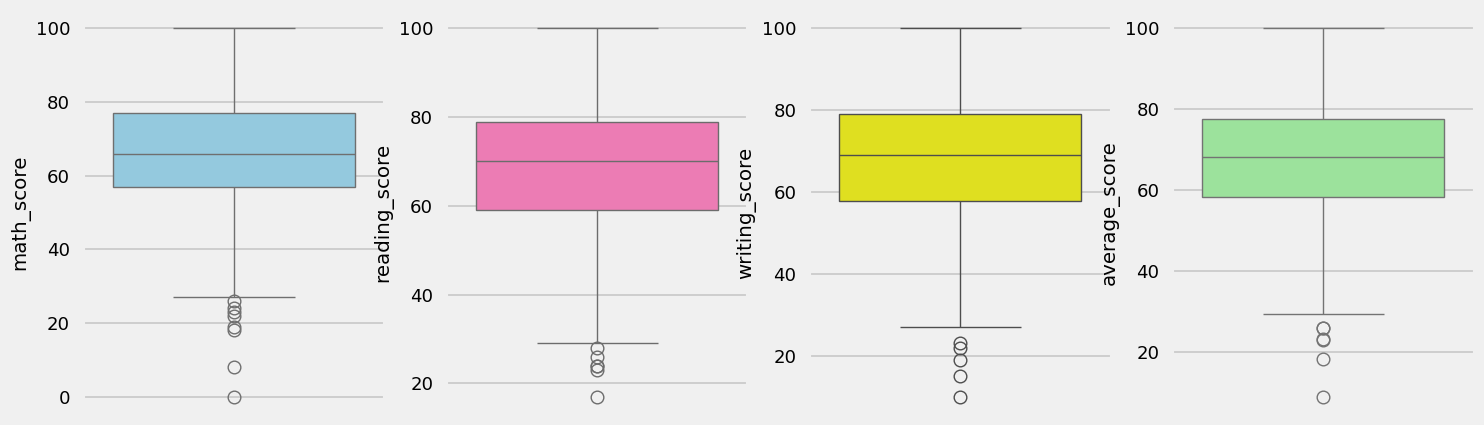

In [64]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average_score'],color='lightgreen')
plt.show()

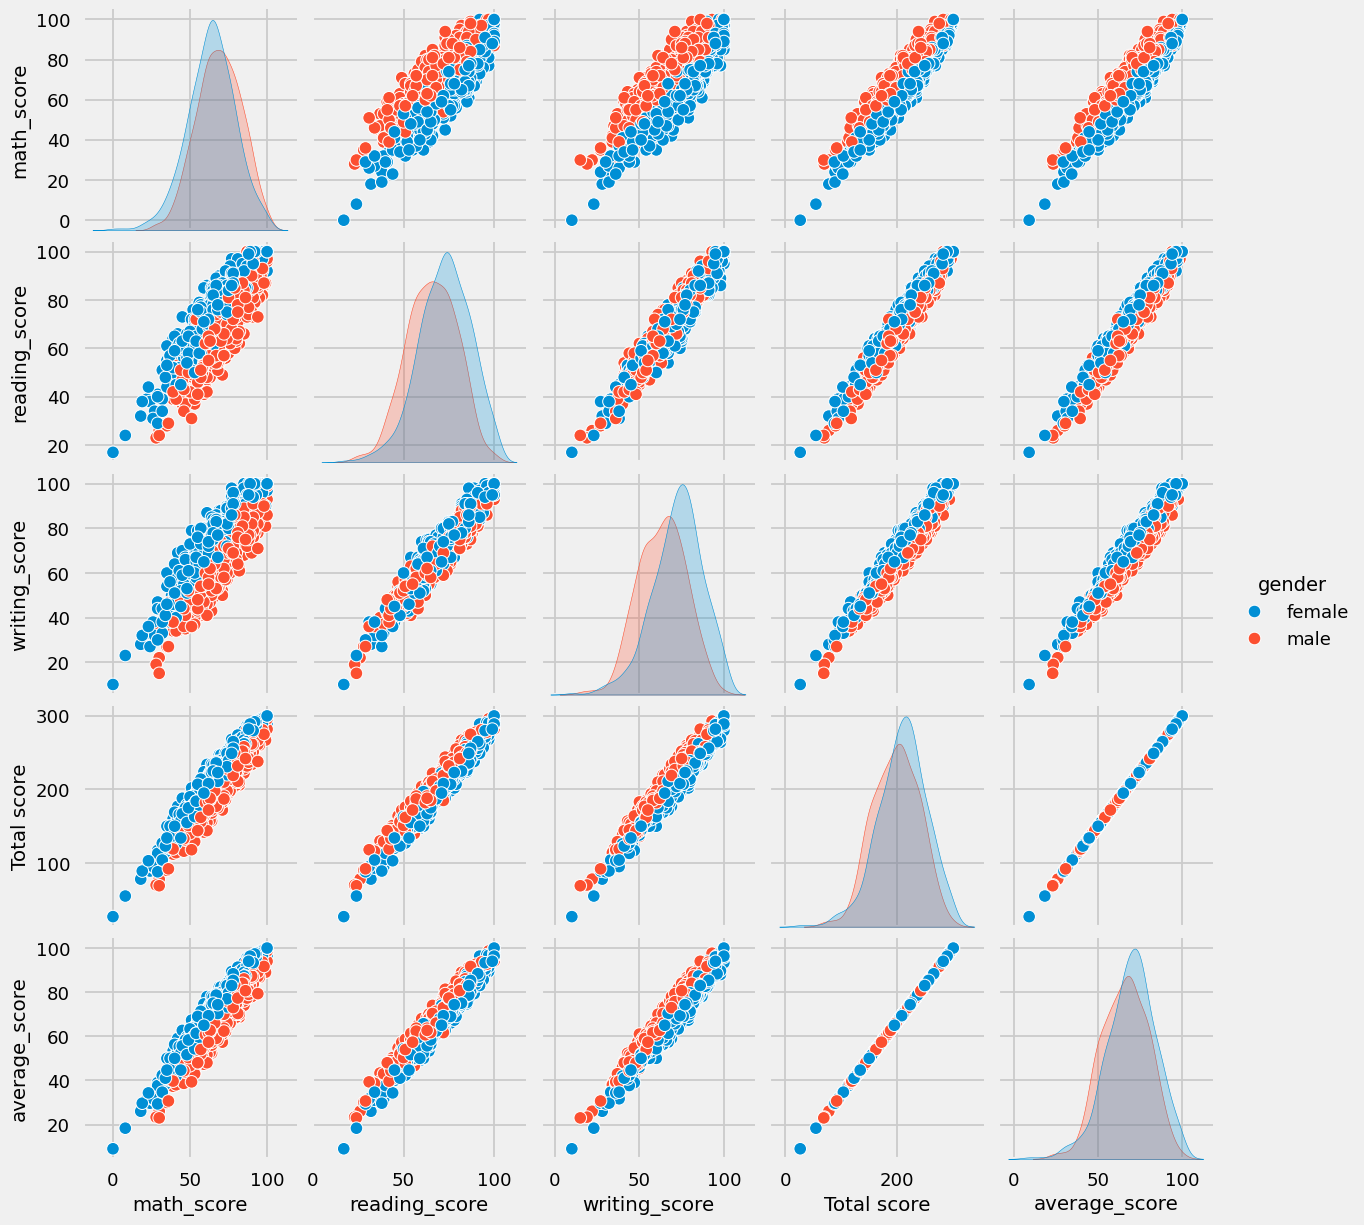

In [65]:
sns.pairplot(df,hue = 'gender')
plt.show()